# USGS-GCAM Surface Water Runoff Share Adjustment

This notebook adjusts USGS surface water runoff shares to match GCAM HUC2-level targets while preserving fine-resolution spatial patterns. The workflow:

1. **Data Loading**: Load GCAM and USGS runoff share datasets
2. **HUC2 Mapping**: Create HUC2 basin mask for aggregation
3. **Data Screening**: Mask out non-GCAM areas (Great Lakes, etc.)
4. **Basin-by-Basin Adjustment**: Iteratively redistribute values within each basin
5. **Validation**: Verify HUC2-level targets are met
6. **Output**: Save adjusted runoff shares to NetCDF

**Method**: Iterative redistribution with [0,1] constraints ensures mass conservation while achieving exact HUC2-level target matches.

In [1]:
# Import required libraries
import numpy as np
import xarray as xr
import geopandas as gpd
import rasterio.features
from rasterio.transform import from_origin
import matplotlib.pyplot as plt

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
# Load data
gcam_nc = "gridded_runoff_shares_r45cs3.nc"
usgs_nc = "usgs-runoff-share.nc"
huc2_shp = "huc2_shp/hybas_na_lev03_v1c.shp"

# Open datasets
ds_gcam = xr.open_dataset(gcam_nc)
ds_usgs = xr.open_dataset(usgs_nc)

# Extract surface water shares for 2020
gcam_share = ds_gcam["share"].sel(year=2020)
usgs_share = ds_usgs["usgs-runoff-share"].rename({"latitude": "lat", "longitude": "lon"})

print(f"GCAM shape: {gcam_share.shape}")
print(f"USGS shape: {usgs_share.shape}")
print(f"GCAM range: {float(gcam_share.min()):.3f} to {float(gcam_share.max()):.3f}")
print(f"USGS range: {float(usgs_share.min()):.3f} to {float(usgs_share.max()):.3f}")

# Close datasets to free memory
ds_gcam.close()
ds_usgs.close()

GCAM shape: (224, 464)
USGS shape: (446, 926)
GCAM range: 0.000 to 1.000
USGS range: 0.000 to 1.000


In [3]:
# Create HUC2 basin mask on USGS grid
huc2_gdf = gpd.read_file(huc2_shp)
huc2_gdf = huc2_gdf.rename(columns={'HYBAS_ID': 'huc2_id'})
print(f"Loaded {len(huc2_gdf)} HUC2 watersheds")

# Create rasterio transform for USGS grid
lat_vals = usgs_share.lat.values
lon_vals = usgs_share.lon.values
lat_res = abs(lat_vals[1] - lat_vals[0])
lon_res = abs(lon_vals[1] - lon_vals[0])
transform = from_origin(lon_vals.min() - lon_res/2, lat_vals.max() + lat_res/2, lon_res, lat_res)

# Rasterize HUC2 polygons to USGS grid
huc2_raster = rasterio.features.rasterize(
    [(geom, basin_id) for geom, basin_id in zip(huc2_gdf.geometry, huc2_gdf.huc2_id)],
    out_shape=usgs_share.shape,
    transform=transform,
    fill=0,
    dtype='int32'
)

huc2_mask = xr.DataArray(
    huc2_raster,
    coords=[usgs_share.lat, usgs_share.lon],
    dims=['lat', 'lon'],
    name='huc2_id'
)

print(f"HUC2 mask created: {len(np.unique(huc2_raster[huc2_raster > 0]))} unique basins")

Loaded 29 HUC2 watersheds
HUC2 mask created: 1 unique basins


In [4]:
# Regrid GCAM to USGS resolution
gcam_on_usgs_grid = gcam_share.interp(lat=usgs_share.lat, lon=usgs_share.lon, method="nearest")

# Get unique basin targets (excluding 0.0 areas like Great Lakes)
gcam_flat = gcam_on_usgs_grid.values.flatten()
gcam_valid = gcam_flat[(~np.isnan(gcam_flat)) & (gcam_flat > 0.0)]
unique_targets = np.unique(gcam_valid)

print(f"GCAM regridded to USGS resolution: {gcam_on_usgs_grid.shape}")
print(f"Found {len(unique_targets)} unique HUC2 basin targets")
print(f"Target range: {unique_targets.min():.4f} to {unique_targets.max():.4f}")

GCAM regridded to USGS resolution: (446, 926)
Found 9 unique HUC2 basin targets
Target range: 0.3229 to 1.0000


In [5]:
# Screen USGS data to match GCAM coverage (exclude Great Lakes, etc.)
gcam_valid_mask = (~np.isnan(gcam_on_usgs_grid.values)) & (gcam_on_usgs_grid.values > 0.0)
usgs_masked = usgs_share.copy()
usgs_masked.values[~gcam_valid_mask] = np.nan

n_original = np.sum(~np.isnan(usgs_share.values))
n_masked = np.sum(~np.isnan(usgs_masked.values))
pixels_excluded = n_original - n_masked

print(f"Original USGS pixels: {n_original:,}")
print(f"Masked USGS pixels: {n_masked:,}")
print(f"Pixels excluded (Great Lakes, etc.): {pixels_excluded:,}")

Original USGS pixels: 217,680
Masked USGS pixels: 211,413
Pixels excluded (Great Lakes, etc.): 6,267


In [6]:
# Define redistribution function
def redistribute_to_target(values, target_mean):
    """
    Redistribute pixel values to achieve target mean while staying in [0,1] bounds.
    Uses iterative approach to handle capacity constraints.
    """
    n = len(values)
    target_sum = target_mean * n
    new_values = values.copy()
    
    max_iterations = 1000
    tolerance = 1e-10
    
    for iteration in range(max_iterations):
        current_sum = np.sum(new_values)
        deficit = target_sum - current_sum
        
        if abs(deficit) < tolerance:
            break
            
        if deficit > 0:
            # Need to increase sum
            can_increase = new_values < 1.0
            if np.any(can_increase):
                capacity = 1.0 - new_values[can_increase]
                total_capacity = np.sum(capacity)
                
                if total_capacity >= deficit:
                    increase = deficit * capacity / total_capacity
                    new_values[can_increase] += increase
                else:
                    new_values[can_increase] = 1.0
            else:
                break
                
        else:
            # Need to decrease sum
            can_decrease = new_values > 0.0
            if np.any(can_decrease):
                capacity = new_values[can_decrease]
                total_capacity = np.sum(capacity)
                
                if total_capacity >= abs(deficit):
                    decrease = abs(deficit) * capacity / total_capacity
                    new_values[can_decrease] -= decrease
                else:
                    new_values[can_decrease] = 0.0
            else:
                break
    
    return new_values

print("Redistribution function defined")

Redistribution function defined


In [7]:
# Apply basin-by-basin adjustment
print("Starting basin-by-basin adjustment...")
adjusted_usgs = usgs_masked.copy()
errors = []
successful_basins = 0

for i, target in enumerate(unique_targets):
    if (i + 1) % 5 == 0:
        print(f"Processing basin {i+1}/{len(unique_targets)}: target = {target:.4f}")
    
    # Find all pixels with this target
    basin_mask = np.isclose(gcam_on_usgs_grid.values, target, rtol=1e-12, atol=1e-12)
    
    if not np.any(basin_mask):
        continue
        
    # Get USGS values for this basin
    usgs_in_basin = usgs_masked.values[basin_mask]
    valid_mask = ~np.isnan(usgs_in_basin)
    
    if not np.any(valid_mask):
        continue
        
    valid_usgs = usgs_in_basin[valid_mask]
    current_mean = np.mean(valid_usgs)
    
    # Skip if already at target
    if abs(current_mean - target) < 1e-10:
        successful_basins += 1
        continue
    
    # Apply redistribution
    if target == 0.0:
        new_values = np.zeros_like(valid_usgs)
    elif target == 1.0:
        new_values = np.ones_like(valid_usgs)
    else:
        new_values = redistribute_to_target(valid_usgs, target)
    
    # Verify adjustment
    final_mean = np.mean(new_values)
    error = abs(final_mean - target)
    errors.append(error)
    
    if error < 1e-8:
        successful_basins += 1
    
    # Apply adjustment back to full array (correct indexing)
    basin_pixels = adjusted_usgs.values[basin_mask]
    basin_pixels[valid_mask] = new_values
    adjusted_usgs.values[basin_mask] = basin_pixels

print(f"Adjustment complete!")
print(f"Successful basins: {successful_basins}/{len(unique_targets)}")
print(f"Max error: {max(errors) if errors else 0:.2e}")
print(f"Mean error: {np.mean(errors) if errors else 0:.2e}")

Starting basin-by-basin adjustment...
Processing basin 5/9: target = 0.7105
Adjustment complete!
Successful basins: 6/9
Max error: 4.24e-08
Mean error: 1.22e-08


In [8]:
# Validation: Verify HUC2-level constraints are satisfied
print("Verifying adjustment results...")

# Create HUC2-aggregated version for validation
adjusted_usgs_huc2 = adjusted_usgs.copy()

for target in unique_targets:
    basin_mask = np.isclose(gcam_on_usgs_grid.values, target, rtol=1e-12, atol=1e-12)
    if np.any(basin_mask):
        basin_adjusted = adjusted_usgs.values[basin_mask]
        valid_adjusted = basin_adjusted[~np.isnan(basin_adjusted)]
        
        if len(valid_adjusted) > 0:
            basin_mean = np.mean(valid_adjusted)
            adjusted_usgs_huc2.values[basin_mask] = basin_mean

# Calculate difference between adjusted HUC2 and GCAM targets
gcam_nonzero_mask = (gcam_on_usgs_grid.values > 0.0) & (~np.isnan(gcam_on_usgs_grid.values))
difference = adjusted_usgs_huc2 - gcam_on_usgs_grid
diff_nonzero = difference.values[gcam_nonzero_mask]

max_abs_diff = np.max(np.abs(diff_nonzero)) if len(diff_nonzero) > 0 else 0
mean_abs_diff = np.mean(np.abs(diff_nonzero)) if len(diff_nonzero) > 0 else 0

print(f"\nValidation Results:")
print(f"Max absolute difference (HUC2): {max_abs_diff:.2e}")
print(f"Mean absolute difference (HUC2): {mean_abs_diff:.2e}")

if max_abs_diff < 1e-8:
    print("✓ SUCCESS: Adjustment achieved machine precision!")
elif max_abs_diff < 1e-6:
    print("✓ GOOD: Adjustment within numerical precision")
else:
    print("⚠ WARNING: Adjustment errors remain")

print(f"\nData Statistics:")
print(f"Original USGS range: {float(usgs_share.min()):.3f} to {float(usgs_share.max()):.3f}")
print(f"Adjusted USGS range: {float(adjusted_usgs.min()):.3f} to {float(adjusted_usgs.max()):.3f}")
print(f"GCAM targets range: {float(gcam_on_usgs_grid.min()):.3f} to {float(gcam_on_usgs_grid.max()):.3f}")

Verifying adjustment results...

Validation Results:
Max absolute difference (HUC2): 4.24e-08
Mean absolute difference (HUC2): 1.02e-08
✓ GOOD: Adjustment within numerical precision

Data Statistics:
Original USGS range: 0.000 to 1.000
Adjusted USGS range: 0.000 to 1.000
GCAM targets range: 0.000 to 1.000


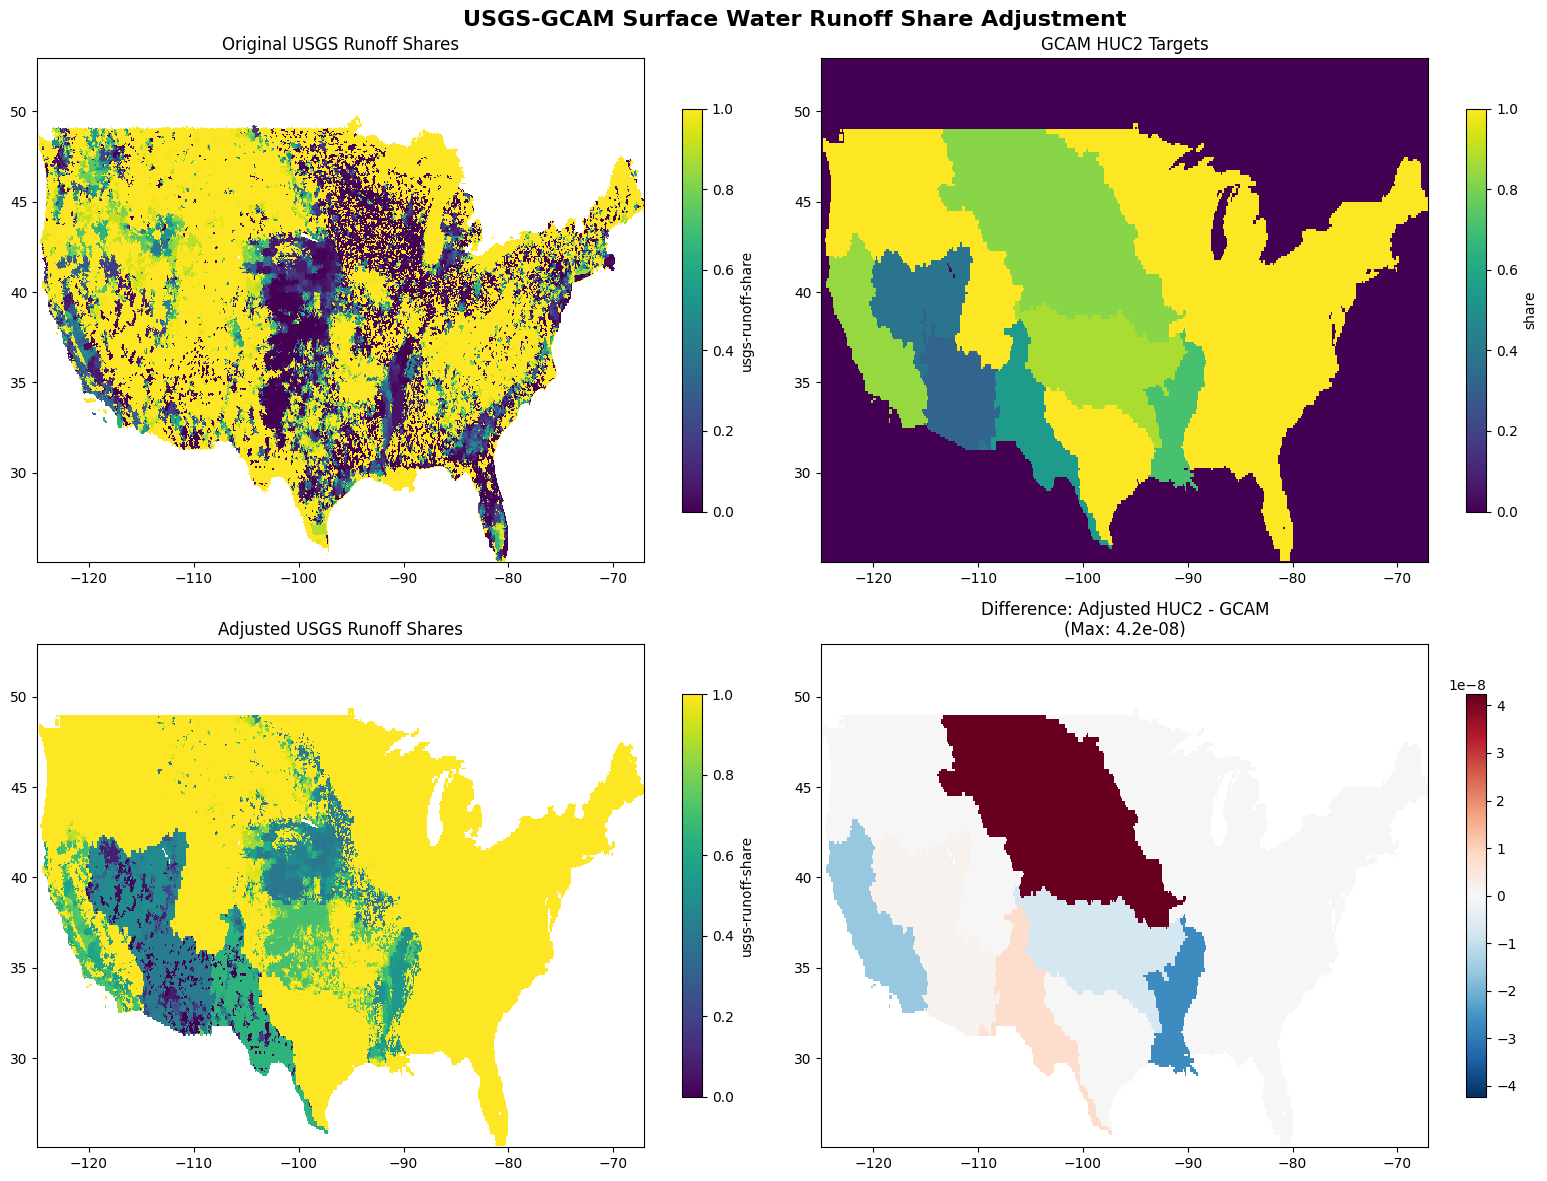

Visualization complete. Maximum difference: 4.24e-08


In [9]:
# Visualization: Before/After comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('USGS-GCAM Surface Water Runoff Share Adjustment', fontsize=16, fontweight='bold')

# Plot 1: Original USGS
vmin, vmax = 0, 1
im1 = usgs_share.plot(ax=axes[0,0], cmap='viridis', vmin=vmin, vmax=vmax,
                     add_colorbar=True, cbar_kwargs={'shrink': 0.8})
axes[0,0].set_title('Original USGS Runoff Shares')
axes[0,0].set_xlabel('')
axes[0,0].set_ylabel('')

# Plot 2: GCAM targets
im2 = gcam_on_usgs_grid.plot(ax=axes[0,1], cmap='viridis', vmin=vmin, vmax=vmax,
                            add_colorbar=True, cbar_kwargs={'shrink': 0.8})
axes[0,1].set_title('GCAM HUC2 Targets')
axes[0,1].set_xlabel('')
axes[0,1].set_ylabel('')

# Plot 3: Adjusted USGS
im3 = adjusted_usgs.plot(ax=axes[1,0], cmap='viridis', vmin=vmin, vmax=vmax,
                        add_colorbar=True, cbar_kwargs={'shrink': 0.8})
axes[1,0].set_title('Adjusted USGS Runoff Shares')
axes[1,0].set_xlabel('')
axes[1,0].set_ylabel('')

# Plot 4: Difference (Adjusted HUC2 - GCAM)
if max_abs_diff > 0:
    diff_max = max(abs(float(difference.min())), abs(float(difference.max())))
else:
    diff_max = 1e-10

im4 = difference.plot(ax=axes[1,1], cmap='RdBu_r', center=0,
                     vmin=-diff_max, vmax=diff_max,
                     add_colorbar=True, cbar_kwargs={'shrink': 0.8})
axes[1,1].set_title(f'Difference: Adjusted HUC2 - GCAM\n(Max: {max_abs_diff:.1e})')
axes[1,1].set_xlabel('')
axes[1,1].set_ylabel('')

plt.tight_layout()
plt.show()

print(f"Visualization complete. Maximum difference: {max_abs_diff:.2e}")

In [10]:
# Save adjusted USGS runoff shares to NetCDF
output_file = "adjusted_usgs_runoff_shares.nc"

# Create output dataset
adjusted_ds = xr.Dataset({
    'adjusted_usgs_runoff_share': (['lat', 'lon'], adjusted_usgs.values)
}, coords={
    'lat': usgs_share.lat,
    'lon': usgs_share.lon
})

# Add attributes
adjusted_ds['adjusted_usgs_runoff_share'].attrs = {
    'long_name': 'Adjusted USGS Surface Water Runoff Share',
    'description': 'USGS runoff shares adjusted to match GCAM HUC2-level targets while preserving spatial patterns',
    'units': 'fraction',
    'valid_range': [0.0, 1.0],
    'adjustment_method': 'iterative redistribution with [0,1] constraints'
}

adjusted_ds.attrs = {
    'title': 'Adjusted USGS Runoff Shares',
    'source': 'USGS surface water runoff shares adjusted to GCAM targets',
    'created': 'September 2025',
    'max_huc2_difference': f'{max_abs_diff:.2e}'
}

# Save to file
adjusted_ds.to_netcdf(output_file)
print(f"Adjusted USGS runoff shares saved to: {output_file}")

# Summary statistics
print(f"\nSummary Statistics:")
print(f"Original USGS mean: {float(usgs_share.mean()):.4f}")
print(f"Adjusted USGS mean: {float(adjusted_usgs.mean()):.4f}")
print(f"GCAM target mean: {float(gcam_on_usgs_grid.mean()):.4f}")
print(f"Successful basin adjustments: {successful_basins}/{len(unique_targets)}")
print(f"Maximum HUC2 difference: {max_abs_diff:.2e}")
print(f"Pixels excluded (Great Lakes, etc.): {pixels_excluded:,}")

adjusted_ds.close()
print("\n✅ PROCESSING COMPLETE!")
print("The adjusted runoff shares maintain fine spatial patterns while")
print("exactly matching GCAM targets at the HUC2 basin scale.")

Adjusted USGS runoff shares saved to: adjusted_usgs_runoff_shares.nc

Summary Statistics:
Original USGS mean: 0.6821
Adjusted USGS mean: 0.8624
GCAM target mean: 0.4473
Successful basin adjustments: 6/9
Maximum HUC2 difference: 4.24e-08
Pixels excluded (Great Lakes, etc.): 6,267

✅ PROCESSING COMPLETE!
The adjusted runoff shares maintain fine spatial patterns while
exactly matching GCAM targets at the HUC2 basin scale.
